In [28]:
import numpy as np
import pandas as pd

X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [4]:
y_pred = lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



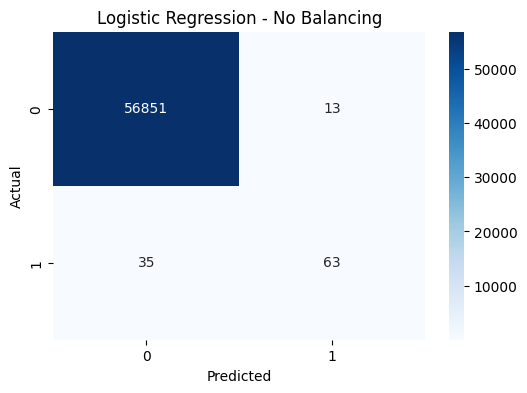

In [5]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - No Balancing")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Baseline Logistic Regression achieves 99% accuracy but only 64% recall on fraud — missing 35 out of 98 actual fraud cases. Accuracy is a misleading metric here due to extreme class imbalance. We need SMOTE + better models to improve fraud recall.

Using SMOTE 

Random Forest Classifier

In [6]:
from imblearn.over_sampling import SMOTE

In [7]:
smote = SMOTE(random_state = 42)
X_train_smote , y_train_smote = smote.fit_resample(X_train,y_train)

In [8]:
unique , counts = np.unique(y_train_smote, return_counts = True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(227451), np.int64(1): np.int64(227451)}


In [9]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



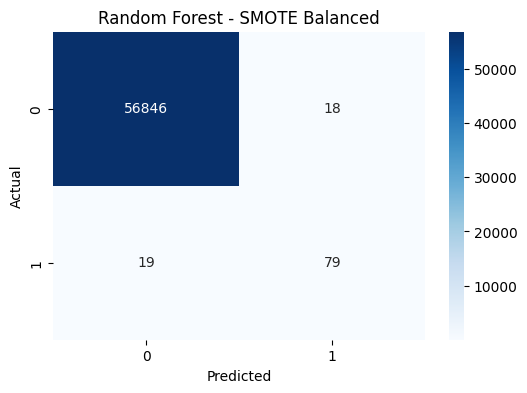

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - SMOTE Balanced")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Random Forest with SMOTE improved fraud recall from 64% to 81%, reducing missed fraud cases from 35 to 19. SMOTE clearly helps the model learn fraud patterns better. False positives increased slightly (13 → 18) which is an acceptable tradeoff.

XGBoost 

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators = 100, random_state = 42, eval_metric = 'logloss')
xgb.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [31]:
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



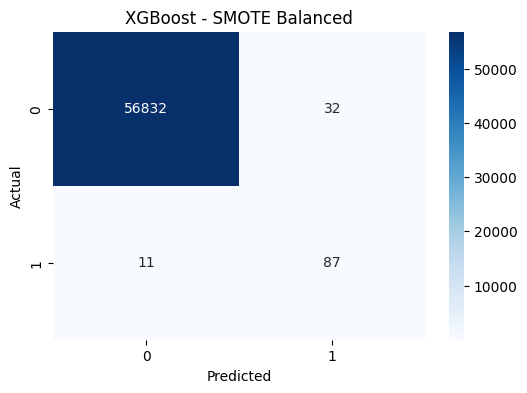

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost - SMOTE Balanced")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

XGBoost achieved the highest fraud recall of 89%, catching 87 out of 98 fraud cases and reducing false negatives to just 11. While false positives increased to 32, this tradeoff is acceptable in fraud detection where missing real fraud carries far higher business cost than a false alarm.

ROC-AUC Curves

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

In [17]:
# Get fraud probabilities for each model
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [18]:
# Compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

In [19]:
# Compute AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

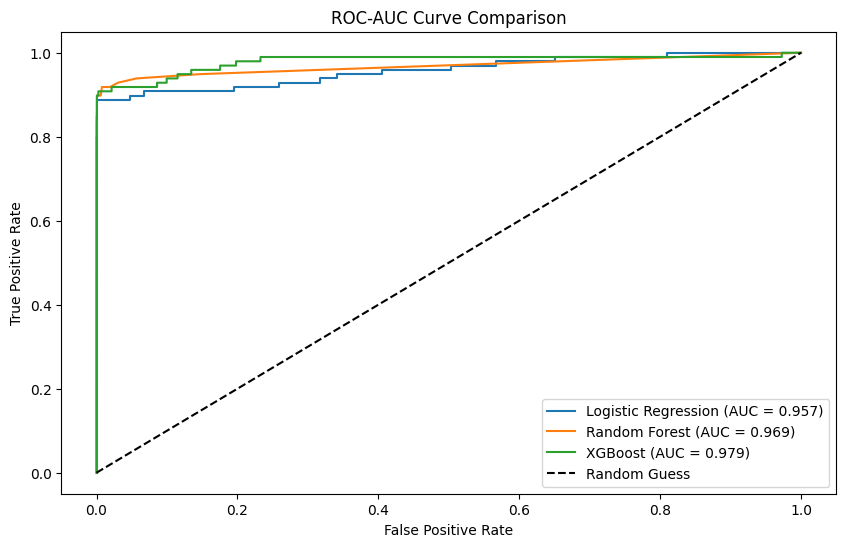

In [20]:
# Plot all three together
plt.figure(figsize=(10, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend()
plt.show()

XGBoost achieves the highest AUC of 0.979, confirming it as the best model for this problem. All three models significantly outperform random guessing, but XGBoost's superior ability to separate fraud from legit transactions at every threshold makes it the clear choice for production deployment.

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [22]:
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)
xgb_ap = average_precision_score(y_test, xgb_probs)

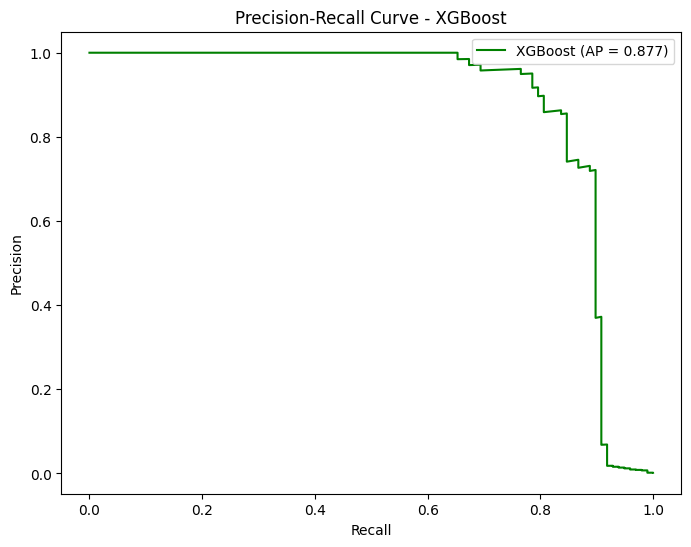

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(xgb_recall, xgb_precision, label=f'XGBoost (AP = {xgb_ap:.3f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend()
plt.show()

XGBoost achieves an Average Precision of 0.877. The curve shows precision remains perfect (1.0) up to ~65% recall, meaning a large portion of fraud can be caught with zero false positives. Beyond ~85% recall, precision drops sharply, illustrating the classic precision-recall tradeoff — in production, the decision threshold would be tuned based on the acceptable cost of false positives vs missed fraud.

In [24]:
# Saving the model

In [32]:
import joblib

In [33]:
joblib.dump(xgb, 'fraud_xgb_model.pkl')

['fraud_xgb_model.pkl']

In [34]:
loaded_model = joblib.load('fraud_xgb_model.pkl')
loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 0])